### Домашнє завдання: Пониження розмірностей для Аналізу Портретів Клієнтів

#### Контекст
В цьому ДЗ ми попрацюємо з методами пониження розмірності на наборі даних для задачі аналізу портретів клієнтів (Customer Personality Analysis). **В попередньому ДЗ ми працювали з цими даними використовуючи кластеризацію, зараз використаємо кластеризацію і візуалізауємо результати з різними методами.**

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


Для початку, запустіть код нижче. Всі ці кроки ми робили в попередньому ДЗ і для того, щоб результати кластеризації у нас були схожими, потрібно аби передобробка була однаковою.

In [99]:
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# 1. Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 3/Data/marketing_campaign.csv', sep='\t')

# 2. Обробка пропущених значень
df['Income_not_filled'] = df.Income.isna()
df.Income = df.Income.fillna(-1)

# 3. Обробка дати реєстрації
df.Dt_Customer = pd.to_datetime(df.Dt_Customer, format='%d-%m-%Y')
today = df.Dt_Customer.max()
df['days_lifetime'] = (today - df.Dt_Customer).dt.days
df['years_customer'] = df.Year_Birth.apply(lambda x: today.year - x)

# 4. Категоризація рівня освіти
df_education = pd.get_dummies(df.Education, prefix='education').astype(int)
df = pd.concat([df, df_education], axis=1)

# 5. Очищення сімейного стану
marital_status_map = {'Alone': 'Single', 'Absurd': 'Else', 'YOLO': 'Else'}
df['Marital_Status_clean'] = df.Marital_Status.map(marital_status_map)
df_ms = pd.get_dummies(df.Marital_Status_clean, prefix='marital').astype(int)
df = pd.concat([df, df_ms], axis=1)

# 6. Форматування доходу і видалення викиду
df.Income = df.Income.astype(int)
df = df[df.Income != 666666]

# 7. Створення фінального набору даних
X = df.drop(['ID', 'Dt_Customer', 'Education', 'Marital_Status', 'Marital_Status_clean'], axis=1)
X.reset_index(drop=True, inplace=True)

### Завдання 1: Виконання кластеризації та пониження розмірності для візуалізації результатів

Ваше завдання — провести кластеризацію клієнтів та візуалізувати результати кластеризації, використовуючи метод головних компонент (PCA) для пониження розмірності даних.

#### Інструкції:

1. **Вибір ключових характеристик:**
   Давайте обмежимось тільки наступними хараткеристиками для кластеризації цього разу:
   - `Income`: Річний дохід домогосподарства клієнта
   - `Recency`: Кількість днів з моменту останньої покупки клієнта
   - `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
   - `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
   - `days_lifetime`: Кількість днів з моменту реєстрації клієнта у компанії
   - `years_customer`: Вік клієнта
   - `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць
   Відберіть в наборі даних `X` лише ці характеристики.

2. **Стандартизація даних:**
   Використайте метод `StandardScaler` для стандартизації значень обраних характеристик.
   
   **Чому не MinMaxScaler:**
   - Для PCA краще використовувати StandardScaler, бо він вирівнює дисперсію ознак, на відміну від MinMaxScaler, що просто масштабує значення без врахування варіації.

   - Для K-Means також краще використовувати StandardScaler, бо алгоритм чутливий до масштабів: фічі з більшими значеннями сильніше впливають на обчислення відстаней, що може спотворити кластери.

3. **Кластеризація:**
   Проведіть кластеризацію клієнтів, використовуючи метод `KMeans` з трьома кластерами.

4. **Пониження розмірності:**
   Використайте метод головних компонент (PCA) для пониження розмірності даних до трьох компонент.

5. **Візуалізація результатів:**
   Використовуючи plolty express побудуйте 3D-графік розподілу клієнтів у просторі трьох головних компонент, де кольором позначено кластери.

6. **Опишіть, що спостерігаєте:**
   Чи кластеризація чітко розділила дані?

Далі ми детальніше проінтерпретуємо результати візуалізації і пониження розмірностей.

Вибір ключових характеристик

In [74]:
# Feature Selection
columns = ['Income', 'Recency', 'NumStorePurchases', 'NumDealsPurchases', 'days_lifetime', 'years_customer', 'NumWebVisitsMonth']
X = df[columns]

# Scaling
standard_scaler = StandardScaler()
data = standard_scaler.fit_transform(X)

data_df = pd.DataFrame(data, columns=X.columns, index=X.index)
display(data_df.head())

,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
0,0.304796,0.306624,-0.551136,0.349782,1.530940,0.984922,0.693887
1,-0.229724,-0.384051,-1.166440,-0.167840,-1.190204,1.235281,-0.130311
2,0.915500,-0.798456,1.294778,-0.685461,-0.205644,0.317300,-0.542410
3,-1.122463,-0.798456,-0.551136,-0.167840,-1.061568,-1.268304,0.281788
4,0.311820,1.549838,0.064169,1.385025,-0.952722,-1.017946,-0.130311


Кластеризація та пониження розмірності PCA

In [75]:
# KMeans
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(data)

labels = kmeans.predict(data)
print(labels)

# PCA
pca = PCA(n_components=3)
pca_data = pca.fit_transform(data)

[1 0 2 ... 2 2 1]


Візуалізація результатів

In [76]:
hover_labels = {f"hover_data_{i}": name for i, name in enumerate(X.columns)}

fig = px.scatter_3d(
    pca_data,
    x = pca_data[:,0],
    y = pca_data[:,1],
    z = pca_data[:,2],
    color = labels,
    hover_data=[X.iloc[:, i].round(2) for i in range(X.shape[1])],
    labels=hover_labels
  )
fig.show()

Отримані кластери чітко розділені

### Завдання 2: Аналіз результатів пониження розмірності

1. **Розрахунок частки поясненої дисперсії:**
   Визначте, яка частка загальної варіації даних пояснюється кожною з трьох головних компонент (PC1, PC2, PC3) за допомогою атрибуту `explained_variance_ratio_` об'єкта PCA. Виведіть результат на екран.

2. **Розрахунок кумулятивної частки поясненої дисперсії:**
   Обчисліть кумулятивну частку поясненої дисперсії для трьох головних компонент, щоб зрозуміти, скільки варіації даних пояснюється першими кількома компонентами.

In [77]:
print('Частка загальної варіації для кожної з трьох компонент:')
print(f'PC1: {pca.explained_variance_ratio_[0].round(4)},\nPC2: {pca.explained_variance_ratio_[1].round(4)}, \nPC3: {pca.explained_variance_ratio_[2].round(4)}')

Частка загальної варіації для кожної з трьох компонент:
PC1: 0.3185,
PC2: 0.1966, 
PC3: 0.1434


0.66


Text(0, 0.5, 'Cumulative Explained Variance')

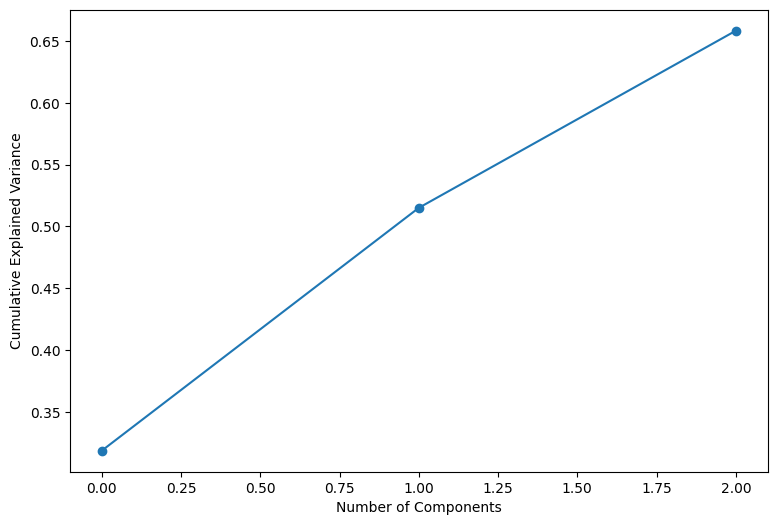

In [78]:
print(np.sum(pca.explained_variance_ratio_).round(2))

plt.figure(figsize=(9, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

Отримали 3 точки відповідно до кожної з компонент.  
Загальна частка пояснення варіації даних першими трьома компонентами є 0.66, тобто 66% варіації даних пояснюється цими трьома компонентами

### Завдання 3: Інтерпретація "Loadings"

Продовжуємо інтерпретацію результатів `PCA`і познайомимось з новим поняттям `loadings`, яке допоможе нам знайти звʼязок між головними компонентами і оригінальними ознаками в наборі даних.

Ми зараз побудували візуалізацію кластерів точок даних в просторі трьох головних компонент. Але хочеться знайти звʼязок між головними компонентами і оригінальними ознаками. Для розуміння, які початкові характеристики даних мають найбільший вплив на ці головні компоненти, ми можемо використати атрибут `components_` методу `PCA`.

#### Що таке `pca.components_`?

`pca.components_` — це масив, який містить коефіцієнти (або "ваги"), що показують внесок кожної вихідної ознаки у кожну з головних компонент. Ці коефіцієнти ще називаються **"loading"** або "навантаженнями" компонент.

- **Loadings** (`навантаження`) відображають важливість кожної змінної (ознаки) для відповідної головної компоненти. Вони показують, яким чином змінні поєднуються, щоб утворити нові, зменшені вимірювання.
- Якщо коефіцієнт має високе абсолютне значення (як позитивне, так і негативне), це вказує на те, що відповідна змінна сильно впливає на головну компоненту.

#### Саме завдання
Ваше завдання — обчислити "навантаження" для кожної з головних компонент і інтерпретувати результати.

1. **Обчислення loadings для компонент:**
   Використайте атрибут `components_` об'єкта PCA для створення DataFrame, який відображатиме внесок кожної вихідної ознаки в кожну головну компоненту.

2. **Інтерпретація результатів:**
   Виведіть значення "навантажень" і проаналізуйте, які ознаки найбільше впливають на кожну головну компоненту.

In [79]:
components_df = pd.DataFrame(
    data=pca.components_,
    columns=X.columns,
    index=['PC1', 'PC2', 'PC3']
)

In [80]:
components_df.round(4)

,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
PC1,0.5842,0.0101,0.4886,-0.1987,-0.1327,0.1894,-0.5717
PC2,0.1653,0.0368,0.3847,0.6081,0.6026,0.2089,0.2163
PC3,-0.0445,0.9758,-0.0806,-0.0348,-0.0222,0.1934,-0.0158


З отриманих результатів бачимо вплив початкових ознак на кожну з компонент:

**РС1**  
  Найбільший вплив ознак:
  - *Income* (+0.58) - позитивний зв'язок, отже до даної компоненти входять клієнти з вищим доходом;
  - *NumWebVisitsMonth* (-0.57) - негативний зв'язок, отже до даної компоненти входять клієнти, які мало відвідують сайт;
  - *NumStorePurchases*	(+0.49) - позитивний зв'язок, клієнти, які більше купують у фізичному магазині

  Отже, дану складову формують клієнти з високим доходом, які надають перевагу здійснювати покупки у фізичному магазині


**РС2**  
  Найбільший вплив ознак:
  - *NumDealsPurchases* (+0.61) - позитивний зв'язок, клієнти з більшою кількістю покупок за знижками;
  - *days_lifetime* (+0.6) - позитивний зв'язок, клієнти, які довгий час зареєстровані

  Отже, дану складову формують лояльні ("давні") клієнти, які багато користуються знижками

**РС3**  
  Найбільший вплив ознаки *Recency* (+0.97) - позитивний зв'язок, клієнти, які мають велику кількість днів від останньої покупки, тобто клієнти, які давно не були активними
  

###Завдання 4
Давайте проаналізуємо "навантаження" (**loadings**) для трьох головних компонент після вилучення ознаки `Income`. Це допоможе нам зрозуміти, як змінилася важливість інших ознак для кожної головної компоненти, коли одна з ключових характеристик (`Income`) була вилучена.

#### Кроки для проведення аналізу і ваше завдання:

1. Видаліть ознаку `Income` з нашого набору даних `X` і повторно виконайте PCA (метод головних компонент) для отримання нових "навантажень".

2. Обчисліть нові "навантаження" для трьох головних компонент на наборі даних без `Income`

3. Проаналізуйте, які ознаки мають найбільший вплив на кожну головну компоненту після вилучення `Income`.

4. Перегляньте, наскільки кожна з головних компонент пояснює дисперсію в даних без ознаки `Income`.

In [69]:
# Feature Selection
columns_noInc = ['Recency', 'NumStorePurchases', 'NumDealsPurchases', 'days_lifetime', 'years_customer', 'NumWebVisitsMonth']
X_noInc = df[columns_noInc]


# Scaling
standard_scaler_noInc = StandardScaler()
data_noInc = standard_scaler_noInc.fit_transform(X_noInc)

data_noInc_df = pd.DataFrame(data_noInc, columns=X_noInc.columns, index=X_noInc.index)
display(data_noInc_df.head())


# KMeans
kmeans_noInc = KMeans(n_clusters=3, n_init='auto')
kmeans_noInc.fit(data_noInc)

labels_noInc = kmeans_noInc.predict(data_noInc)


# PCA
pca_noInc = PCA(n_components=3)
pca_data_noInc = pca_noInc.fit_transform(data_noInc)


#Plotting
hover_labels_noInc = {f"hover_data_{i}": name for i, name in enumerate(X_noInc.columns)}

fig = px.scatter_3d(
    pca_data_noInc,
    x = pca_data_noInc[:,0],
    y = pca_data_noInc[:,1],
    z = pca_data_noInc[:,2],
    color = labels_noInc,
    hover_data=[X_noInc.iloc[:, i].round(2) for i in range(X_noInc.shape[1])],
    labels=hover_labels_noInc
  )
fig.show()

,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
0,0.306624,-0.551136,0.349782,1.530940,0.984922,0.693887
1,-0.384051,-1.166440,-0.167840,-1.190204,1.235281,-0.130311
2,-0.798456,1.294778,-0.685461,-0.205644,0.317300,-0.542410
3,-0.798456,-0.551136,-0.167840,-1.061568,-1.268304,0.281788
4,1.549838,0.064169,1.385025,-0.952722,-1.017946,-0.130311


In [70]:
components_noInc_df = pd.DataFrame(
    data=pca_noInc.components_,
    columns=X_noInc.columns,
    index=['PC1', 'PC2', 'PC3']
)

display(components_noInc_df.round(4))

,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
PC1,-0.0144,-0.3812,0.4456,0.3838,-0.1773,0.6908
PC2,0.0749,0.6292,0.4615,0.4679,0.3936,-0.1079
PC3,0.9902,-0.1111,-0.0618,0.0068,0.0563,0.0099


Після вилучення Income бачимо вплив початкових ознак на кожну з компонент:

**РС1**  
  Найбільший вплив ознак:
  - *NumWebVisitsMonth* (+0.69) - позитивний зв'язок, отже до даної компоненти входять клієнти з великою кількістю відвідування сайту;
  - *NumDealsPurchases*	(+0.45) - позитивний зв'язок, клієнти, які здійснюють багато покупок за знижками

  Отже, дану складову формують клієнти, які користуються сайтом та здійснюють велику кількість покупок здебільшого на сайті. Тобто це активні онлайн-клієнти


**РС2**  
  Найбільший вплив ознак:
  - *NumStorePurchases* (+0.63) - позитивний зв'язок, клієнти з більшою кількістю покупок у фізичному магазині;
  - *days_lifetime* (+0.47) - позитивний зв'язок, клієнти, які довгий час зареєстровані;
  - *NumDealsPurchases* (+0.46) - позитивний зв'язок, клієнти, які здійснюють багато покупок за знижками

  Отже, дану складову формують лояльні ("давні") офлайн-клієнти, які надають перевагу знижкам

**РС3**  
  Найбільший вплив ознаки *Recency* (+0.99) - позитивний зв'язок, клієнти, які мають велику кількість днів від останньої покупки, тобто клієнти, які давно не були активними

Характеристики головних компонент змінилися для РС1 та РС2, РС3 по суті залишилася без змін

In [71]:
print('Частка загальної варіації для кожної з трьох компонент:')
print(f'PC1: {pca_noInc.explained_variance_ratio_[0].round(4)},\nPC2: {pca_noInc.explained_variance_ratio_[1].round(4)}, \nPC3: {pca_noInc.explained_variance_ratio_[2].round(4)}')

Частка загальної варіації для кожної з трьох компонент:
PC1: 0.2739,
PC2: 0.2144, 
PC3: 0.1668


0.66


Text(0, 0.5, 'Cumulative Explained Variance')

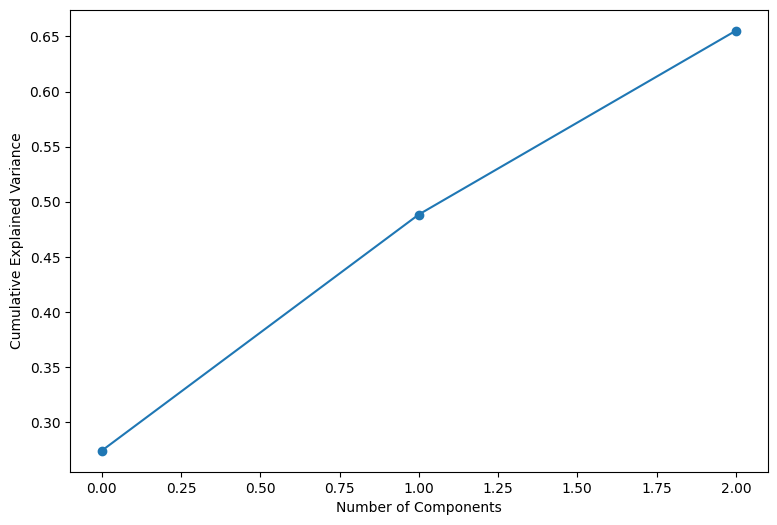

In [72]:
print(np.sum(pca_noInc.explained_variance_ratio_).round(2))

plt.figure(figsize=(9, 6))
plt.plot(np.cumsum(pca_noInc.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

Бачимо, що загальна сума пояснення дисперсії трьома компонентами не змінилася, проте змінився розподіл пояснення дисперсії між компонентами (РС1 менше пояснює дисперсію без Income).

### Завдання 5: Візуалізація кластеризації за допомогою t-SNE

Ваше завдання — використати метод t-SNE для візуалізації результатів кластеризації клієнтів у двовимірному просторі. Метод t-SNE допомагає знизити розмірність даних та зберегти локальні структури в даних, що робить його ефективним для візуалізації високорозмірних даних. Ми також зможемо порівняти результат цього методу з РСА.

1. Використайте метод t-SNE для зниження розмірності до 2х вимірів даних, які включають ознаки всі, що і в завданні 1, а також були відмасштабовані перед пониженням розмірностей.

2. Створіть новий DataFrame з координатами, отриманими після застосування t-SNE, та додайте до нього мітки кластерів.

3. Побудуйте інтерактивний 2D-графік розподілу клієнтів, де кольором буде позначено різні кластери і проаналізуйте графік з рекомендаціями нижче (можливо треба буде вивести додаткові візуалізації чи таблиці для інтерпретації, але треба прям зрозуміти, які ознаки формують який кластер і чим кластери відрізняються одне від одного).

  **Опишіть отримані кластери з точки зору ознак.**

4. Опишіть відмінність графіка tSNE від PCA.

#### ЯК можна інтерпретувати з t-SNE?

Хоча t-SNE не надає "компонентів" як РСА, він забезпечує низьковимірне представлення даних, яке можна візуально інтерпретувати:

- **Кластери:** t-SNE особливо добре показує кластери подібних точок. Якщо ви бачите чітко визначені кластери на графіку t-SNE, це свідчить про наявність груп схожих спостережень у ваших даних. Проаналізувати їх можемо, якщо додамо дані в `hover_data` або якщо якісь з даних виведемо як розмір чи форма точок на візуалізації. Також корисно може бути вивести середні значення ознак по кластерам.
- **Локальна структура:** Відносне розташування точок одного кластеру на графіку t-SNE може допомогти вам зрозуміти, які дані подібні між собою.
- **Глобальна структура:** Будьте обережні; t-SNE менш надійний для відображення глобальних структур (наприклад, відстаней між кластерами) у порівнянні з PCA, бо t-SNE націлений на збереження саме локальних структур.

In [83]:
tsne = TSNE(n_components=2, random_state=42)
tsne_data = tsne.fit_transform(data)

In [87]:
tsne_df = pd.DataFrame(
    data=tsne_data,
    columns=['t-SNE 1', 't-SNE 2']
)

tsne_df['Label'] = labels.astype(str)

In [89]:
#Plotting
hover_labels_tsne = {f"hover_data_{i}": name for i, name in enumerate(X.columns)}

fig = px.scatter(
    tsne_df,
    x = tsne_df['t-SNE 1'],
    y = tsne_df['t-SNE 2'],
    color = tsne_df['Label'],
    hover_data=[X.iloc[:, i].round(2) for i in range(X.shape[1])],
    labels=hover_labels_tsne
  )
fig.show()

На графіку видно наявність 3-х чітких кластерів, отже в наборі даних дійсно є групи схожих спостережень.

Розміри кластерів:


In [93]:
tsne_df['Label'].value_counts().sort_index()

,count
Label,
0,962
1,454
2,823


Бачимо, що найбільший кластер з Label 0, другий за розміром Label 2, найменший (майже в 2 рази менший за два інші) Label 1.


Проаналізуємо середні значення ознак по сформованих кластерах

In [107]:
profile_std = data_df.assign(Label=labels).groupby('Label').mean().round(2)
display(profile_std)

,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
Label,,,,,,,
0,-0.83,-0.02,-0.80,-0.26,-0.20,-0.27,0.49
1,0.02,0.03,0.28,1.39,0.78,0.25,0.64
2,0.96,0.01,0.78,-0.46,-0.19,0.18,-0.93


In [101]:
profile = X.assign(Label=labels).groupby('Label').mean().round(2)
display(profile)

,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
Label,,,,,,,
0,33077.67,48.48,3.18,1.81,312.27,41.93,6.51
1,51943.98,50.08,6.71,5.00,510.52,48.23,6.87
2,72551.55,49.35,8.34,1.44,315.25,47.35,3.07


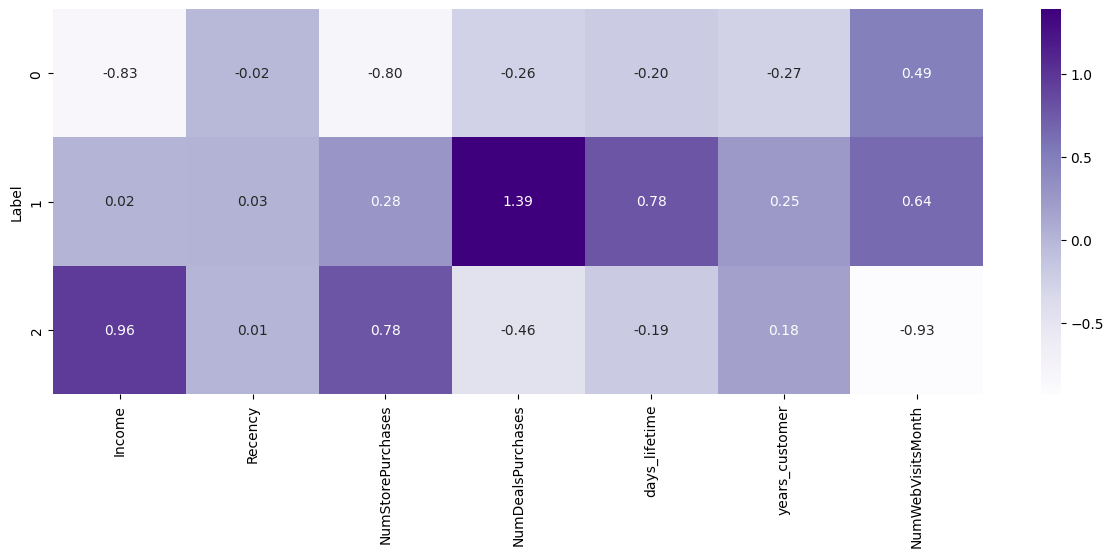

In [108]:
plt.figure(figsize=(15,5))
sns.heatmap(profile_std, cmap="Purples", annot=True, fmt=".2f")
plt.show()

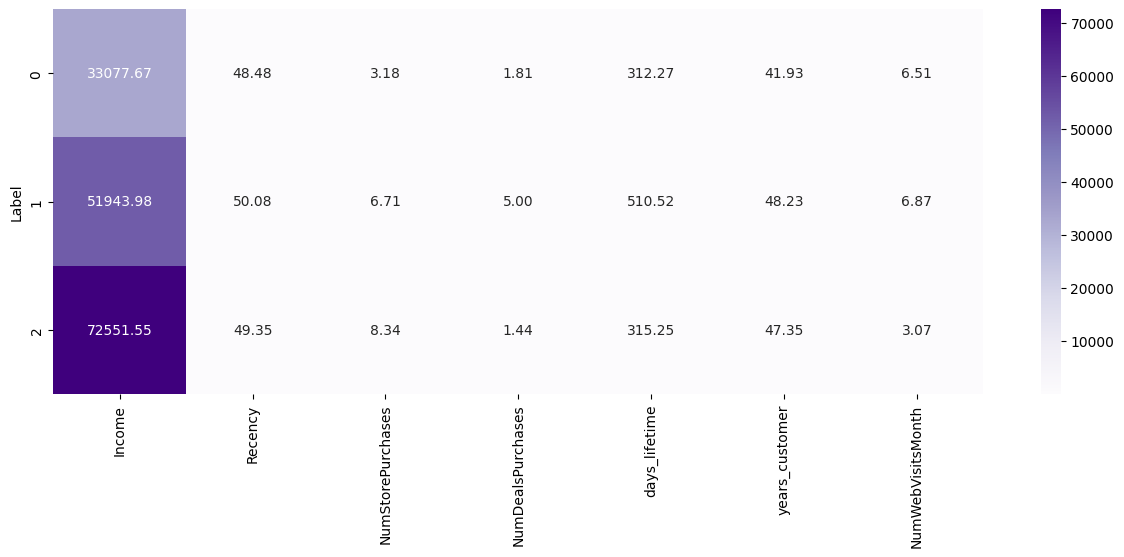

In [109]:
plt.figure(figsize=(15,5))
sns.heatmap(profile, cmap="Purples", annot=True, fmt=".2f")
plt.show()

З отриманих візуалізацій та таблиць можна зробити наступні висновки щодо отриманих кластерів:

**Кластер 1** (Label 0) - клієнти з нижчим доходом, низькою кількістю покупок у фізичному магазині та досить високою кількістю відвідувань сайту.
Фактично, кластер охоплює не дуже платоспроможних клієнтів, які можуть шукати знижки на сайті магазину. Найбільший за кількістю клієнтів кластер.

**Кластер 2** (Label 1) - клієнти із середнім доходом, середньою кількістю покупок в фізичному магазині, найбільшою кількістю покупок за знижками, найдовшим "стажем" та високою кількістю відвідувань сайту. Фактично, кластер охоплює лояльних клієнтів, які часто користуються знижками. Найменший за розміром кластер.

**Кластер 3** (Label 2) - клієнти з високим доходом, найбільшою кількістю покупок у фізичному магазині, найменшою кількістю покупок за знижками та найменшою кількістю відвідувань сайту. Отже, кластер охоплює клієнтів з високим доходом та частими покупками, які в основному не зацікавлені знижками та сайтом магазину. Порівняно великий розмір кластеру


Також з графіка розташування кластерів видно, що кластери досить чітко між собою розділені, та кластери мають дещо розмиті межі, зокрема за рахунок розміру доходу та "часу життя" клієнта.

На відміну від графіка РСА, графік t-SNE не зберігає явно покази викидів, які можна побачити на РСА як поодинокі точки, віддалені від основної частини свого кластера